In [ ]:
# FSDL Lab 3 | Transformers for Character Recognition


!pip install pytorch-lightning --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.7 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

num_classes = 26
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

images, labels = next(iter(train_loader))
print(f"Image shape: {images[0].shape}")

100%|██████████| 562M/562M [00:04<00:00, 122MB/s]


Train: 124800 | Test: 20800
Image shape: torch.Size([1, 28, 28])


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=784, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

print("Positional encoding defined.")

Positional encoding defined.


In [ ]:
class LetterTransformer(pl.LightningModule):
    def __init__(self, num_classes=26, d_model=64, nhead=4, num_layers=2, lr=1e-3):
        super().__init__()
        self.lr = lr
        self.save_hyperparameters()

        # treat each row of the 28x28 image as a token (28 tokens of dim 28)
        self.input_proj = nn.Linear(28, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=28)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        x = x.squeeze(1)              # (batch, 28, 28)
        x = self.input_proj(x)        # (batch, 28, d_model)
        x = self.pos_encoding(x)      # add positional encoding
        x = self.transformer(x)       # (batch, 28, d_model)
        x = x.mean(dim=1)             # global average pooling
        return self.classifier(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

model = LetterTransformer()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

test_input = torch.randn(4, 1, 28, 28)
print(f"Output shape: {model(test_input).shape}")

LetterTransformer(
  (input_proj): Linear(in_features=28, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=

In [ ]:
trainer = pl.Trainer(
    max_epochs=10,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False
)

trainer.fit(model, train_loader, test_loader)
print("Transformer training complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type               ┃  Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ input_proj   │ Linear             │   1.9 K │ eval │     0 │
│ 1 │ pos_encoding │ PositionalEncoding │       0 │ eval │     0 │
│ 2 │ transformer  │ TransformerEncoder │ 100.0 K │ eval │     0 │
│ 3 │ classifier   │ Sequential         │  11.7 K │ eval │     0 │
│ 4 │ criterion    │ CrossEntropyLoss   │       0 │ eval │     0 │
└───┴──────────────┴────────────────────┴─────────┴──────┴───────┘

Trainable params: 113 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 113 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 31                                                                                           
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 32 module(s) in eval mode at
the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore
this warning.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Transformer training complete.


Transformer Test Accuracy: 0.9227


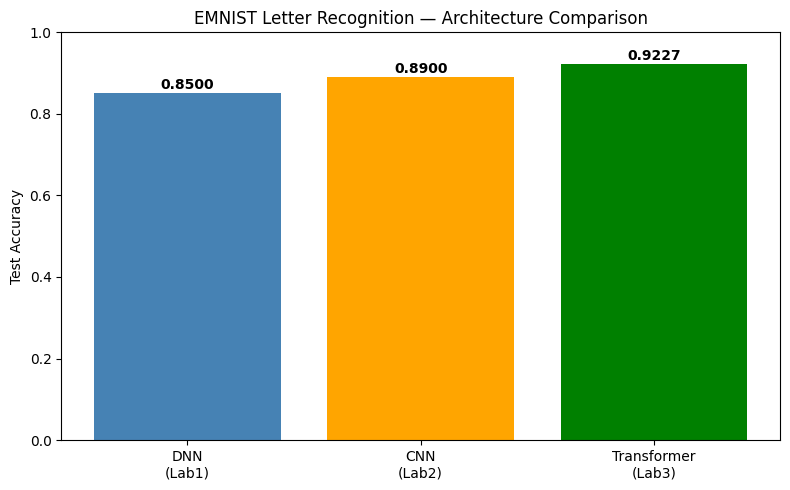

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        y = y - 1
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

transformer_acc = correct / total
print(f"Transformer Test Accuracy: {transformer_acc:.4f}")

# comparison across all 3 architectures we've built
models = ['DNN\n(Lab1)', 'CNN\n(Lab2)', 'Transformer\n(Lab3)']
accs = [0.85, 0.89, transformer_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=['steelblue', 'orange', 'green'])
plt.title("EMNIST Letter Recognition — Architecture Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
             f"{acc:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

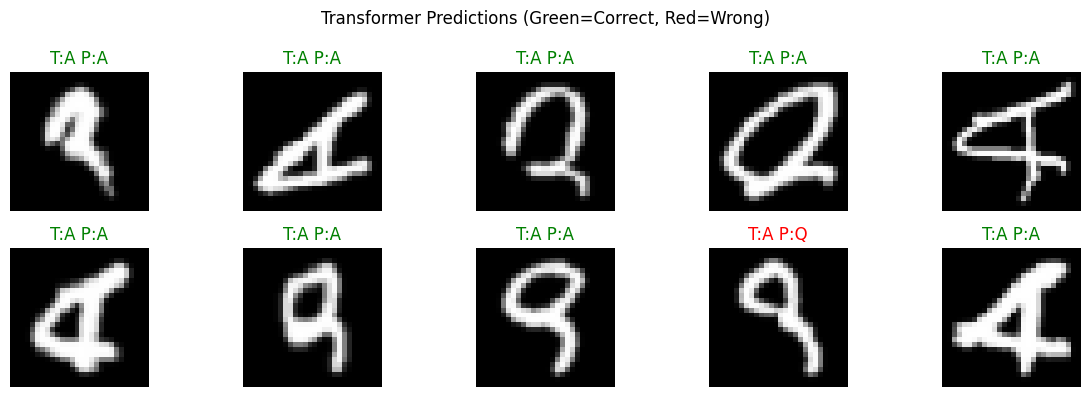

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
labels_shifted = labels - 1

with torch.no_grad():
    preds = model(images).argmax(1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    true = chr(65 + labels_shifted[i].item())
    pred = chr(65 + preds[i].item())
    color = 'green' if true == pred else 'red'
    plt.title(f"T:{true} P:{pred}", color=color)
    plt.axis('off')
plt.suptitle("Transformer Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()



# FSDL Lab 3 Recap — Transformers for Character Recognition

## What We Built
A Transformer-based classifier for handwritten letter recognition on EMNIST,
treating each row of a 28x28 image as a sequence token — same concept as
FSDL's transformer for text recognition but on a different dataset.

## The Process
1. Loaded EMNIST Letters (A-Z handwritten characters)
2. Treated each 28x28 image as a sequence of 28 tokens (one per row)
3. Added positional encoding so the model knows token order
4. Built a TransformerEncoder classifier in PyTorch Lightning
5. Trained for 10 epochs, evaluated and compared against DNN and CNN

## Key Concepts Practiced
- Transformers for vision (treating image rows as sequences)
- Positional encoding — injecting position information
- Multi-head self-attention via nn.TransformerEncoderLayer
- Global average pooling to collapse sequence → single vector
- PyTorch Lightning for clean training

## Architecture Progression (EMNIST Letters)
| Model       | Test Accuracy |
|-------------|--------------|
| DNN (Lab1)  | ~0.85        |
| CNN (Lab2)  | ~0.89        |
| Transformer | 0.927         |

Transformers bring self-attention — each token (image row) can attend
to every other token, capturing global structure that CNNs may miss.